# CSDA STAC search: multiple vendors' data at Sites (AERONET-OC)

Summary:  
+ read in a sites geojson
+ compile a STAC search at site for a time period for vendor imagery
+ plot the footprints of the results

#### Resources:
+ https://nasa-impact.github.io/csda-client/latest/examples/search-and-download/#finding-planet-data

| Author | Affiliation | Date |
| ---------------- | ---------------- | ---------------- |
| Paul Montesano, PhD | NASA Goddard Space Flight Center; ESSIC | Sept 2026 |

In [ ]:
#pip install contextily
#pip install matplotlib_scalebar

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from urllib.parse import quote
import numpy as np

import sys

# sys.path.append('/projects/code/csda_summaries/lib')
sys.path.append('/home/pmontesa/code/csda_summaries/lib')

import csdalib
import staclib
import siteslib

from datetime import datetime
from multiprocessing import Pool, cpu_count
from functools import partial
from tqdm import tqdm
import importlib

In [2]:
from pathlib import Path
STAC_CACHE_PATH = Path("/explore/nobackup/people/pmontesa/stac_cache")
STAC_CACHE_PATH.mkdir(parents=True, exist_ok=True)

## CSDA Evaluation Sites

Our database of `CSDA Evaluation Sites` is a critical & foundational set of information for CSDA SME work. Each site, uniquely identified with a `Site Name` and a specific geographic extent (AOI), provides some sort of radiometric or geometric reference for evaluation commercial imagery.

#### Read in our CSDA sites GeoJSON (AOIs) directly from GitHub

In [85]:
RAW_BASE = 'https://raw.githubusercontent.com/pahbs/csda_summaries/master'

SITES_STR = 'eval' #'csda'

sites_url = f'{RAW_BASE}/sites/{SITES_STR}_sites_aoi.geojson'

sites_gdf = gpd.read_file(sites_url)
print(f"{sites_gdf.shape[0]} site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.")

613 site AOIs, which are extents of various sizes and shapes, ranging from tiny corner reflector locations, to boxes and circles, to larger custom polygons.


In [86]:
sites_gdf.Source.unique()

array(['NASA', 'RadCalNet', 'KIT', 'JPL', 'DLR', 'USGS', 'ESA',
       'USGS 3DEP', 'NEON', 'USDA', 'SkyCam', 'BELMANIP2', 'AERONET',
       'AERONET-OC', 'HyperNAV', 'National Data Buoy System'],
      dtype=object)

In [87]:
BUF_KM = 0

In [88]:
DO_SITE_SUBSET = True
AERONETOC = True
DO_GLOBAL = False

In [89]:
if DO_SITE_SUBSET:
    if AERONETOC:
        SITES_LIST = ['AERONET-OC', 'HyperNAV']
        SITES_STR = '_'.join(SITES_LIST)
        #sites_gdf = sites_gdf[sites_gdf.Source == SITES_STR]
        sites_gdf = sites_gdf[sites_gdf.Source.isin(SITES_LIST)]
SITES_STR
sites_gdf.shape

(26, 27)

# Table of CSDA STAC Collections

Here is what data we can find in the CSDA STAC

In [92]:
import pystac_client

# Define target CSDA STAC endpoint
STAC_URL = "https://csdap.earthdata.nasa.gov/stac"

try:
    # 1. Test API connection and structural validation
    print(f"Connecting to {STAC_URL}...")
    catalog = pystac_client.Client.open(STAC_URL)
    print(f"SUCCESS: Connected to API ID: {catalog.id}")
    #print(f"STAC Version supported: {catalog.stac_version}\n")
    
    # 2. Test the query engine by pulling a single item limit
    print("Testing search capabilities...")
    search = catalog.search(max_items=1)
    items = list(search.items())
    
    print(f"SUCCESS: Search engine returned {len(items)} record(s) correctly.")
    
except Exception as e:
    print(f"API ERROR: Connection or query parsing failed.\nDetails: {e}")


Connecting to https://csdap.earthdata.nasa.gov/stac...
SUCCESS: Connected to API ID: stac-fastapi
Testing search capabilities...
SUCCESS: Search engine returned 1 record(s) correctly.


In [93]:
import requests
from IPython.display import Markdown, display

STAC_API_URL = 'https://csdap.earthdata.nasa.gov/stac'

# Get collections
response = requests.get(f'{STAC_API_URL}/collections')
data = response.json()

collections = data.get('collections', [])

# Build markdown
markdown_output = f"# CSDA STAC Collections\n\n"
markdown_output += f"**Total Collections:** {len(collections)}\n\n"
markdown_output += "| ID | Title | Description | Temporal Coverage |\n"
markdown_output += "|:---|:---|:---|:---|\n"

for collection in collections:
    col_id = collection.get('id', 'N/A')
    title = collection.get('title', 'N/A')
    description = collection.get('description', 'N/A')
    
    # Truncate and clean description
    if description and description != 'N/A':
        description = description.replace('\n', ' ').replace('\r', '')
        if len(description) > 100:
            description = description[:100] + '...'
        description = description.replace('|', '\\|')
    
    # Get temporal extent with safe None checks
    temporal_str = 'N/A'
    try:
        extent = collection.get('extent')
        if extent and isinstance(extent, dict):
            temporal = extent.get('temporal')
            if temporal and isinstance(temporal, dict):
                intervals = temporal.get('interval', [])
                if intervals and isinstance(intervals, list) and len(intervals) > 0:
                    if intervals[0] and isinstance(intervals[0], list) and len(intervals[0]) > 0:
                        start = intervals[0][0] if intervals[0][0] else 'Unknown'
                        end = intervals[0][1] if len(intervals[0]) > 1 and intervals[0][1] else 'Present'
                        
                        # Format dates nicely
                        if isinstance(start, str) and start not in ['Unknown', 'N/A']:
                            start = start.split('T')[0]
                        if isinstance(end, str) and end not in ['Present', 'N/A']:
                            end = end.split('T')[0]
                        
                        temporal_str = f"{start} to {end}"
    except Exception as e:
        # If anything goes wrong, just leave as N/A
        pass
    
    # Create collection link
    collection_url = f"{STAC_API_URL}/collections/{col_id}"
    col_id_link = f"[{col_id}]({collection_url})"
    
    markdown_output += f"| {col_id_link} | {title} | {description} | {temporal_str} |\n"

# Display in notebook
display(Markdown(markdown_output))

# Save to file
with open(f'{STAC_CACHE_PATH}/stac_collections.md', 'w') as f:
    f.write(markdown_output)

print("\n✓ Saved to stac_collections.md")

# CSDA STAC Collections

**Total Collections:** 19

| ID | Title | Description | Temporal Coverage |
|:---|:---|:---|:---|
| [umbra](https://csdap.earthdata.nasa.gov/stac/collections/umbra) | Umbra | Umbra Space | 2023-11-02 to 2026-09-12 |
| [desis](https://csdap.earthdata.nasa.gov/stac/collections/desis) | DESIS | Teledyne Brown Engineering, Inc – DESIS | 2018-08-30 to 2024-05-25 |
| [pixxel](https://csdap.earthdata.nasa.gov/stac/collections/pixxel) | Pixxel | Pixxel | 2025-06-21 to 2026-06-13 |
| [planetiq](https://csdap.earthdata.nasa.gov/stac/collections/planetiq) | PlanetiQ | PlanetiQ | 2024-01-18 to 2025-03-24 |
| [satellogic](https://csdap.earthdata.nasa.gov/stac/collections/satellogic) | Satellogic | Satellogic Inc. | 2021-02-02 to 2026-09-09 |
| [geooptics](https://csdap.earthdata.nasa.gov/stac/collections/geooptics) | GeoOptics | geooptics | 2020-01-01 to 2021-04-30 |
| [spire](https://csdap.earthdata.nasa.gov/stac/collections/spire) | Spire | Spire | 2019-11-01 to 2025-08-09 |
| [airbus-dem](https://csdap.earthdata.nasa.gov/stac/collections/airbus-dem) | Airbus - DEM | Airbus - DEM | 2025-09-19 to 2026-04-13 |
| [iceye](https://csdap.earthdata.nasa.gov/stac/collections/iceye) | Iceye | ICEYE US | 2019-10-17 to 2026-09-12 |
| [tomorrow](https://csdap.earthdata.nasa.gov/stac/collections/tomorrow) | Tomorrow | The Tomorrow Companies Inc. | 2023-06-24 to 2026-02-22 |
| [pgc-earthdem](https://csdap.earthdata.nasa.gov/stac/collections/pgc-earthdem) | EarthDEM | EarthDEM | 2002-02-06 to 2024-07-01 |
| [maxar-sdx](https://csdap.earthdata.nasa.gov/stac/collections/maxar-sdx) | Maxar DEM | Maxar Technologies – Precision 3D | 2008-01-18 to 2025-05-26 |
| [capellaspace](https://csdap.earthdata.nasa.gov/stac/collections/capellaspace) | CapellaSpace | capellaspace | 2020-12-26 to 2026-09-13 |
| [maxar-legion](https://csdap.earthdata.nasa.gov/stac/collections/maxar-legion) | Maxar Legion | Maxar Technologies Inc. | 2024-09-11 to 2026-09-09 |
| [airbus](https://csdap.earthdata.nasa.gov/stac/collections/airbus) | Airbus U.S.- SAR | Airbus U.S. | 2007-11-19 to 2026-08-20 |
| [airbus-optical](https://csdap.earthdata.nasa.gov/stac/collections/airbus-optical) | Airbus U.S.- Optical | Airbus U.S.- Optical | 2021-08-15 to 2026-08-30 |
| [ghgsat](https://csdap.earthdata.nasa.gov/stac/collections/ghgsat) | GHGSat | GHGSat | 2021-01-03 to 2026-08-13 |
| [blacksky](https://csdap.earthdata.nasa.gov/stac/collections/blacksky) | BlackSky | BlackSky Technology, Inc. | 2019-05-07 to 2026-08-17 |
| [planet](https://csdap.earthdata.nasa.gov/stac/collections/planet) | Planet | Planet | 2009-03-09 to 2026-07-18 |



✓ Saved to stac_collections.md


### Create site dicts for all sites

In [94]:
def create_global_grid(grid_size=30):
    """
    Create a grid of sub-regions covering the globe.
    
    Parameters:
    -----------
    grid_size : int
        Size of each grid cell in degrees (default 30° = 12x6 grid)
    
    Returns:
    --------
    dict : Dictionary of site_dicts for each grid cell
    """
    site_dicts = {}
    
    # Create grid from -180 to 180 longitude, -90 to 90 latitude
    lons = range(-180, 180, grid_size)
    lats = range(-90, 90, grid_size)
    
    for i, lon_start in enumerate(lons):
        for j, lat_start in enumerate(lats):
            lon_end = min(lon_start + grid_size, 180)
            lat_end = min(lat_start + grid_size, 90)
            
            # Create unique name for this grid cell
            grid_name = f"grid_{i:02d}_{j:02d}"
            
            # Calculate center point
            center_lon = (lon_start + lon_end) / 2
            center_lat = (lat_start + lat_end) / 2
            
            site_dicts[grid_name] = {
                'bbox': [lon_start, lat_start, lon_end, lat_end],
                'lon': center_lon,
                'lat': center_lat,
                'buffer': None,
                'geom_type': 'Polygon'
            }
    
    return site_dicts

In [95]:
# Usage in your code:
if DO_GLOBAL:
    # Global search - break into grid
    SITENAME = 'Global'
    SITES_STR = SITENAME.replace(' ', '.')
    
    # Create grid (adjust grid_size as needed: 30°, 20°, 10°, etc.)
    site_dicts = create_global_grid(grid_size=10)  # 30° = 12x6 = 72 regions
    
    print(f"Global search broken into {len(site_dicts)} sub-regions")
else:
    site_dicts = staclib.create_site_dict_from_gdf(sites_gdf, site_name_field='Site Name', buffer_degrees=0)

# Convert to list of tuples for processing
CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

In [96]:
len(site_dicts)

26

# Multiprocess search across all CSDA Evaluation Sites for a vendor

### Configure search

In [97]:
TODAY = datetime.now().strftime('%Y-%m-%d')
START_OF_COMMERCIAL_ERA = '1999-01-01'

In [99]:
# Misc search
COLLECTION_LIST = ['planet']
YEAR = 'allyears'
START_DATE = START_OF_COMMERCIAL_ERA
# YEAR = 2024
# START_DATE = f'{YEAR}-01-01'
END_DATE = TODAY
#END_DATE = '2019-12-31'
MONTH_LIST = list(range(1,12+1))

In [100]:
CSDA_EVAL_SITE_ITEMS = list(site_dicts.items())

### Multiprocess SDX search across CSDA Eval sites

In [101]:
import importlib
importlib.reload(staclib)

<module 'staclib' from '/home/pmontesa/code/csda_summaries/lib/staclib.py'>

In [103]:
search_func = partial(staclib.stac_search_site, end_date=END_DATE, start_date=START_DATE,  months=MONTH_LIST,
                      collections=COLLECTION_LIST
                     )
#search_func = partial(search_site, today=today, start_date='2010-01-01', collections=['maxar'])

n_processes = max(1, cpu_count() - 2)
print(f"Using {n_processes} processes to search {len(CSDA_EVAL_SITE_ITEMS)} sites\n")

# Run with progress bar
with Pool(processes=n_processes) as pool:
    results = list(tqdm(
        pool.imap(search_func, CSDA_EVAL_SITE_ITEMS),
        total=len(CSDA_EVAL_SITE_ITEMS),
        desc="Searching sites"
    ))

# Collect and report results
stac_gdf_list = []
stac_items_list = []
print("\nResults by site:")
for site_name, gdf, items, message in results:
    print(f"  {site_name}: {message}")
    if gdf is not None:
        stac_gdf_list.append(gdf)
        stac_items_list.extend(items)

# Combine
if stac_gdf_list:
    stac_gdf = pd.concat(stac_gdf_list, ignore_index=True)
    print(f"\n{'='*60}")
    print(f"Total: {len(stac_gdf)} items from {stac_gdf['site_name'].nunique()} sites")
    print(f"{'='*60}")
    print("\nItems per site:")
    print(stac_gdf['site_name'].value_counts())
else:
    print("\nNo items found")
    stac_gdf = gpd.GeoDataFrame()

Using 22 processes to search 26 sites



Searching sites: 100%|██████████| 26/26 [00:15<00:00,  1.63it/s]



Results by site:
  AAOT: Found 669 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Bahia_Blanca: Found 6 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Casablanca_Platform: Found 7 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Gustav_Dalen_Tower: Found 7 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Irbe_Lighthouse: Found 5 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  RdP-EsNM: Found 2 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Section-7_Platform: Found 82 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  USC_SEAPRISM: Found 1868 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  WaveCIS_Site_CSI_6: Found 769 items across 28 interval(s) (months=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
  Chesapeake_Bay: Found 2503 items across 28 inte

In [104]:
#ic[100].assets
stac_gdf.shape

(12429, 183)

## Save items & footprints: 

SDX STAC search results to JSON & geopackage

In [105]:
from pystac import ItemCollection

ic = ItemCollection(stac_items_list)
ic.save_object(str(STAC_CACHE_PATH / f"stac_items_{SITES_STR}_{'_'.join(COLLECTION_LIST)}_{YEAR}.json"))

In [106]:
stac_gdf = stac_gdf.drop(columns=[col for col in stac_gdf.columns if 'asset' in col])

# Convert list columns to strings
stac_gdf_copy = stac_gdf.copy()
for col in stac_gdf_copy.columns:
    if stac_gdf_copy[col].apply(lambda x: isinstance(x, list)).any():
        stac_gdf_copy[col] = stac_gdf_copy[col].apply(lambda x: str(x) if isinstance(x, list) else x)
        
stac_gdf_copy.to_file(str(STAC_CACHE_PATH / f"stac_{SITES_STR}_{'_'.join(COLLECTION_LIST)}_{YEAR}.gpkg"))

## Plot STAC results info

In [107]:
#stac_gdf[['pl:provider', 'pl:item_type','pl:satellite_id', 'pl:product_id','collection', 'eo:instrument']]

In [108]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
from shapely.geometry import Polygon

from matplotlib.colors import LogNorm

In [109]:
# 1. Define target projection string
eckert_vi_crs  = '+proj=eck6  +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m +no_defs'
robinson_crs   = '+proj=robin +lon_0=0 +x_0=0 +y_0=0 +ellps=WGS84 +datum=WGS84 +units=m +no_defs'

# 2. Build local offline global boundary canvas 
try:
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
except (AttributeError, FileNotFoundError):
    world_box = Polygon([(-180, -90), (-180, 90), (180, 90), (180, -90)])
    world = gpd.GeoDataFrame(index=[0], crs='EPSG:4326', geometry=[world_box])

world_projected = world.to_crs(robinson_crs)
xmin, ymin, xmax, ymax = world_projected.total_bounds

In [110]:
%%time
# 3. Process STAC centroids safely - with filter tracking
filters_applied = []

# Start with full dataset
heatmap_df = stac_gdf.copy()
initial_count = len(heatmap_df)

# Apply filters and track them
# Filter 1: Remove duplicates
DEDUP_COL = 'id'
heatmap_df = heatmap_df.drop_duplicates(subset=[DEDUP_COL])

if len(heatmap_df) < initial_count:
    filters_applied.append(f"Duplicates removed using col '{DEDUP_COL}': {initial_count - len(heatmap_df)}")
    initial_count = len(heatmap_df)

CPU times: user 35.7 ms, sys: 248 µs, total: 36 ms
Wall time: 34.8 ms


In [111]:
stac_gdf.head()

,id,collection,datetime,geometry,bbox,eo:gsd,eo:epsg,pl:rows,eo:bands,pl:columns,...,pl:camera_id,pl:data_type,pl:granule_id,pl:product_id,pl:datatake_id,pl:mgrs_grid_id,pl:abs_orbit_number,pl:rel_orbit_number,pl:s2_processor_version,pl:product_generation_time
0,PSScene3Band-20181231_093622_100e,planet,2018-12-31T09:36:22.12257Z,"POLYGON ((12.54568 45.37950, 12.51937 45.30474...","[12.519365165388093, 45.25257009776177, 12.866...",3.9,32633.0,4922.0,[],9107.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PSScene4Band-20181230_093619_1035,planet,2018-12-30T09:36:19.709496Z,"POLYGON ((12.39777 45.35476, 12.40379 45.37323...","[12.380292277032844, 45.24746131671897, 12.724...",3.9,32633.0,4895.0,[],9026.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,PSScene3Band-20181230_093619_1035,planet,2018-12-30T09:36:19.709496Z,"POLYGON ((12.40379 45.37323, 12.38002 45.30027...","[12.380018935607037, 45.24740507446436, 12.726...",3.9,32633.0,4898.0,[],9067.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,PSScene4Band-20181218_093658_100c,planet,2018-12-18T09:36:58.078493Z,"POLYGON ((12.46164 45.22284, 12.14330 45.27505...","[12.143300336738083, 45.222839224720296, 12.48...",3.9,32633.0,4872.0,[],8978.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,PSScene3Band-20181218_093658_100c,planet,2018-12-18T09:36:58.078493Z,"POLYGON ((12.16727 45.34746, 12.14330 45.27505...","[12.143303463979615, 45.22249482850864, 12.487...",3.9,32633.0,4887.0,[],9017.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Platform field created/updated. Unique values: ['PS2' 'PS2.SD' 'PSB.SD' 'rapideye' 'skysat' 'esa']


/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2717894/548594912.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  heatmap_df['centroid_geom'] = heatmap_df['geometry'].centroid
/explore/nobackup/people/pmontesa/.nccstmp/ipykernel_2717894/548594912.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


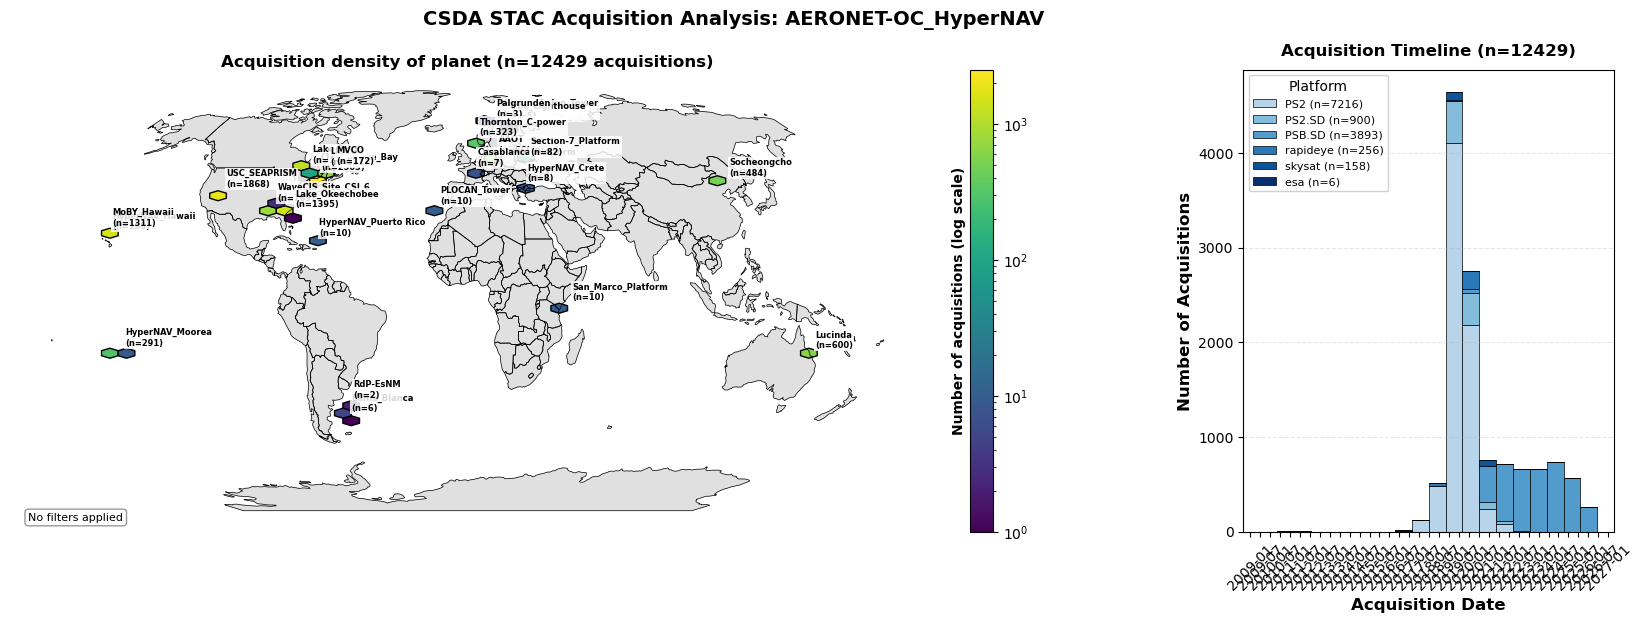

In [112]:
# Filter 2: Exclude specific values across multiple columns
EXCLUDE_STR_LIST = ['PAN', 'PSH','Ortho']
EXCLUDE_COL_LIST = ['csda:item_type', 'platform','pl:item_type']

# All possible fields across CSDA STAC that indicate platform
platform_fields = ['platform',
                   'pl:provider',
                   'eo:instrument',
                   'pl:satellite_id',
                   'eo:platform',
                   'satellite_id', 'instrument',
                   'collection']

# Ensure platform column exists
if 'platform' not in heatmap_df.columns:
    heatmap_df['platform'] = None

# Fill platform from available fields in priority order
for field in platform_fields:
    if field in heatmap_df.columns:
        heatmap_df['platform'] = heatmap_df['platform'].fillna(heatmap_df[field])

# Check which column is available to fill the planetscope details
if 'eo:instrument' in heatmap_df.columns:
    instrument_col = heatmap_df['eo:instrument']
elif 'sensor' in heatmap_df.columns:
    instrument_col = heatmap_df['platform']
else:
    instrument_col = 'planetscope'  # Keep original value if nothing else is found

heatmap_df['platform'] = heatmap_df['platform'].mask(
    heatmap_df['platform'] == 'planetscope',
    instrument_col
).fillna('Unknown')

#heatmap_df['platform'] = heatmap_df['platform'].fillna('Unknown')

print(f"Platform field created/updated. Unique values: {heatmap_df['platform'].unique()}")

# Build combined exclusion mask
exclude_mask = pd.Series([False] * len(heatmap_df), index=heatmap_df.index)  # Match index

for col in EXCLUDE_COL_LIST:
    if col in heatmap_df.columns:
        exclude_mask |= heatmap_df[col].isin(EXCLUDE_STR_LIST)

# Count total exclusions
exclude_count = exclude_mask.sum()
if exclude_count > 0:
    exclude_str = ', '.join(EXCLUDE_STR_LIST)
    col_str = ', '.join(EXCLUDE_COL_LIST)
    filters_applied.append(f"{exclude_str} excluded from {col_str}: {exclude_count}")

# Apply filter
heatmap_df = heatmap_df[~exclude_mask]

# Add more filters as needed in the future:
# heatmap_df = heatmap_df[heatmap_df['eo:cloud_cover'] < 20]
# filters_applied.append("Cloud cover < 20%")

# Create filter text for annotation
if filters_applied:
    filter_text = "Filters applied:\n" + "\n".join([f"• {f}" for f in filters_applied])
else:
    filter_text = "No filters applied"

heatmap_df['centroid_geom'] = heatmap_df['geometry'].centroid
centroid_gdf = gpd.GeoDataFrame(heatmap_df, geometry='centroid_geom', crs=stac_gdf.crs)
centroid_projected = centroid_gdf.to_crs(eckert_vi_crs)

centroid_projected['x'] = centroid_projected.geometry.x
centroid_projected['y'] = centroid_projected.geometry.y

sites_unique = centroid_projected.dropna(subset=['site_name']).drop_duplicates(subset=['site_name'])

collections = [c for c in centroid_projected['collection'].unique() if pd.notna(c)]
num_collections = len(collections)
xmin_land, ymin_land, xmax_land, ymax_land = world_projected.total_bounds

# ============ CREATE COMBINED FIGURE ============
# Use gridspec for better control
fig = plt.figure(figsize=(22, 6), facecolor='white')
gs = fig.add_gridspec(1, 2, width_ratios=[3, 1], wspace=0.3)

# LEFT SUBPLOT: Hexbin map
ax_map = fig.add_subplot(gs[0])

# Assuming single collection for simplicity - adjust if needed
col_name = collections[0]
ax_map.set_facecolor('white')
world_projected.plot(ax=ax_map, color='#e0e0e0', edgecolor='#cccccc', linewidth=0.3)

col_data = centroid_projected[centroid_projected['collection'] == col_name]
num_col_images = col_data.shape[0]

if not col_data.empty:
    # Get approximate max for norm (you can adjust this)
    max_val = col_data.groupby([pd.cut(col_data['x'], bins=50), 
                                  pd.cut(col_data['y'], bins=50)]).size().max()
    
    hb = ax_map.hexbin(
        col_data['x'], col_data['y'],
        gridsize=50,
        cmap='viridis',
        mincnt=1,
        edgecolors='black',
        alpha=1,
        norm=LogNorm(vmin=1, vmax=max_val),
        extent=[xmin_land, xmax_land, ymin_land, ymax_land]
    )

# Site labels
site_counts = col_data['site_name'].value_counts().to_dict()
active_sites_in_col = col_data['site_name'].unique()
col_sites = sites_unique[sites_unique['site_name'].isin(active_sites_in_col)]

for _, row in col_sites.iterrows():
    s_name = row['site_name']
    n_images_site = site_counts.get(s_name, 0)
    label_text = f"{s_name}\n(n={n_images_site})"
    
    if "Railroad Valley" in s_name:
        x_offset, y_offset = -25, 10
    elif "Sioux Falls" in s_name:
        x_offset, y_offset = 15, 10
    else:
        x_offset, y_offset = 5, 5
    
    ax_map.annotate(
        text=label_text,
        xy=(row['x'], row['y']),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=6,
        fontweight='bold',
        color='black',
        zorder=6,
        bbox=dict(boxstyle="square,pad=0.15", fc="white", ec="none", alpha=0.85)
    )

ax_map.text(0.02, 0.02, filter_text, 
            transform=ax_map.transAxes,
            fontsize=8,
            verticalalignment='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))

# Put black world outline on top
world_projected.plot(ax=ax_map, facecolor='none', edgecolor='black', linewidth=0.5)

# ax_map.set_xlim(xmin_land * 0.75, xmax_land * 0.9)
# ax_map.set_ylim(ymin_land * 0.75, ymax_land * 1.02)
ax_map.set_title(f"Acquisition density of {col_name} (n={num_col_images} acquisitions)", fontsize=12, fontweight='bold', pad=0)
ax_map.axis('off')

# Add colorbar for hexbin with log scale
cbar = plt.colorbar(hb, ax=ax_map, fraction=0.046, pad=0.04)
cbar.set_label('Number of acquisitions (log scale)', rotation=90, labelpad=-55, fontweight='bold')

# RIGHT SUBPLOT: Timeline histogram
ax_timeline = fig.add_subplot(gs[1])

timeline_df = heatmap_df.copy()
#timeline_df['start_datetime'] = pd.to_datetime(timeline_df['start_datetime'])

# Determine which datetime field to use
if 'start_datetime' in timeline_df.columns:
    # Use start_datetime if it exists, fill datetime NAs with it
    timeline_df['datetime'] = pd.to_datetime(timeline_df['datetime'])
    timeline_df['start_datetime'] = pd.to_datetime(timeline_df['start_datetime'])
    timeline_df['datetime'] = timeline_df['datetime'].fillna(timeline_df['start_datetime'])
else:
    # Just use datetime if start_datetime doesn't exist
    timeline_df['datetime'] = pd.to_datetime(timeline_df['datetime'])

# Use datetime for the plot
timeline_df_plot = timeline_df.copy()
timeline_df_plot['acquisition_date'] = timeline_df_plot['datetime']

platform_order = ['GE01', 'WV01', 'WV02', 'WV03', 'WV04', 'LG01', 'LG02', 'LG03', 'LG04', 'LG05', 'LG06', 'LG07', 'LG08', 'LG09']
actual_platforms = timeline_df['platform'].dropna().unique()
platforms = [p for p in platform_order if p in actual_platforms]
platforms.extend([p for p in actual_platforms if p not in platform_order])

colors = plt.cm.Blues(np.linspace(0.3, 1, len(platforms)))
color_dict = dict(zip(platforms, colors))

platform_data = []
platform_labels = []
for p in platforms:
    p_data = timeline_df[timeline_df['platform'] == p]['datetime']
    platform_data.append(p_data)
    platform_labels.append(f"{p} (n={len(p_data)})")

ax_timeline.hist(platform_data, 
                 bins=20, 
                 stacked=True, 
                 label=platform_labels,
                 color=[color_dict[p] for p in platforms],
                 edgecolor='black', 
                 linewidth=0.5)

ax_timeline.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax_timeline.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax_timeline.tick_params(axis='x', rotation=45)

ax_timeline.set_xlabel('Acquisition Date', fontsize=12, fontweight='bold')
ax_timeline.set_ylabel('Number of Acquisitions', fontsize=12, fontweight='bold')
ax_timeline.set_title(f"Acquisition Timeline (n={num_col_images})", fontsize=12, fontweight='bold', pad=10)
ax_timeline.legend(title='Platform', loc='upper left', framealpha=0.9, fontsize=8)
ax_timeline.grid(True, alpha=0.3, linestyle='--', axis='y')

plt.suptitle(f'CSDA STAC Acquisition Analysis: {SITES_STR}', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()